### EDA of final dataset

In [2]:
# === Packages
import pandas as pd
import numpy as np
from seaborn import histplot, pairplot
from matplotlib.pyplot import subplots, axvline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
#from imblearn.over_sampling import SMOTE

In [15]:
# Read dataset
#df = pd.read_csv('../data/final_datasets/raw_datasets/raw_reduced_training_data.csv')
df = pd.read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df_over = pd.read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_oversampled2_training_data.csv')

In [25]:
df.head()

,gndvi_median_res10,datt1_median_res10,fs_median_res10,siwsi_median_res10,ndmi_median_res10,si_median_res10,w_median_res10,evi_median_res10,B2_median_res10,B3_median_res10,...,B12_median_res500,lst_median_res10,lst_median_res250,lst_median_res500,polygon_density_250,mean_number_of_floors_250,units_density_250,population_density_250,air_temperature_at_surface [degC],UHI Index
0,0.226649,0.559904,0.834542,-0.023708,0.011038,2.000000,-552.00720,1.335894,1053.0,1155.0,...,1909.779553,40.762629,39.472107,39.296610,32.0,3.817092,2433.0,4447.0,26.644576,1.030289
1,0.226649,0.559904,0.834542,-0.023708,0.011038,2.000000,-552.00720,1.335894,1053.0,1155.0,...,1908.549839,40.762629,39.328660,39.301969,31.0,3.787208,2415.0,4447.0,26.644576,1.030289
2,0.462794,0.758538,0.733204,0.185049,0.182898,0.480226,-341.93740,1.777562,646.0,823.0,...,1909.880645,39.926923,39.291284,39.318334,32.0,3.808673,2470.0,4447.0,26.644576,1.023798
3,0.483479,0.733288,0.733204,0.185049,0.173959,0.652482,-381.95745,1.857962,625.0,766.0,...,1912.327476,39.926923,39.313410,39.358855,32.0,3.789108,2437.0,4951.0,26.644576,1.023798
4,0.478112,0.745955,0.746522,0.149468,0.143840,-0.053140,-484.02280,2.475712,659.5,763.0,...,1913.190476,39.550941,39.299802,39.380734,32.0,3.792808,2491.0,4951.0,26.644576,1.021634


In [26]:
# Check all columns names
for col in df.columns:
    print(col)

gndvi_median_res10
datt1_median_res10
fs_median_res10
siwsi_median_res10
ndmi_median_res10
si_median_res10
w_median_res10
evi_median_res10
B2_median_res10
B3_median_res10
B4_median_res10
B5_median_res10
B7_median_res10
B8_median_res10
B8A_median_res10
B11_median_res10
B12_median_res10
gndvi_median_res100
fs_median_res100
siwsi_median_res100
ndmi_median_res100
si_median_res100
w_median_res100
evi_median_res100
B2_median_res100
B3_median_res100
B4_median_res100
B5_median_res100
B6_median_res100
B11_median_res100
B12_median_res100
gndvi_median_res250
fs_median_res250
siwsi_median_res250
ndmi_median_res250
si_median_res250
w_median_res250
evi_median_res250
B2_median_res250
B3_median_res250
B4_median_res250
B5_median_res250
B6_median_res250
B7_median_res250
B8_median_res250
B8A_median_res250
B11_median_res250
B12_median_res250
gndvi_median_res500
fs_median_res500
siwsi_median_res500
ndmi_median_res500
w_median_res500
evi_median_res500
B2_median_res500
B3_median_res500
B4_median_res500
B5_me

In [27]:
# Statistical description of the dataset
df.describe()

,gndvi_median_res10,datt1_median_res10,fs_median_res10,siwsi_median_res10,ndmi_median_res10,si_median_res10,w_median_res10,evi_median_res10,B2_median_res10,B3_median_res10,...,B12_median_res500,lst_median_res10,lst_median_res250,lst_median_res500,polygon_density_250,mean_number_of_floors_250,units_density_250,population_density_250,air_temperature_at_surface [degC],UHI Index
count,11229.000000,11227.000000,11229.000000,11229.000000,11229.000000,11226.000000,11229.000000,11229.000000,11229.000000,11229.000000,...,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000
mean,0.225783,0.245086,0.847365,0.015862,-0.009703,2.301488,-719.383712,1.039231,1201.538071,1341.301852,...,1858.152336,38.736647,38.465371,38.043788,21.457298,4.724359,2293.052632,4468.931071,26.985717,1.000001
std,0.175793,13.542193,0.114139,0.108804,0.132000,11.245002,419.157800,4.297828,497.517654,508.824965,...,316.114736,2.530493,2.355364,2.351789,14.102242,2.901016,1671.513354,3033.716125,0.414890,0.016238
min,-0.187701,-467.000000,0.430006,-0.263642,-0.558525,-551.000000,-3622.744200,-194.000000,266.000000,320.000000,...,762.355556,30.117206,29.711423,29.504444,0.000000,0.000000,0.000000,0.000000,26.197958,0.956122
25%,0.095206,0.157163,0.799305,-0.058147,-0.096386,0.875000,-922.012400,0.340114,905.000000,1031.500000,...,1678.098413,37.452277,37.536468,36.771528,12.000000,3.158742,1208.000000,2128.000000,26.716900,0.988577
50%,0.165601,0.704268,0.875716,-0.012691,-0.024390,2.049355,-658.653200,0.828185,1145.000000,1269.000000,...,1894.285714,38.986968,38.799612,38.573003,19.000000,4.029226,2043.000000,4474.000000,26.984223,1.000237
75%,0.309578,0.917404,0.925828,0.060644,0.063419,3.265795,-446.502250,1.700381,1394.000000,1538.000000,...,2091.762058,40.302905,39.861873,39.583140,28.000000,5.915556,3088.000000,6346.000000,27.180084,1.011176
max,0.806583,407.000000,1.095450,0.413566,0.443110,347.000000,1063.897500,89.375000,5256.000000,5444.000000,...,2542.575806,49.991283,45.829778,42.681924,86.000000,26.450000,8836.000000,15643.000000,28.304176,1.046036


In [28]:
for column, value in zip(df.columns, df.isna().sum()):
    print(column, value)

gndvi_median_res10 0
datt1_median_res10 2
fs_median_res10 0
siwsi_median_res10 0
ndmi_median_res10 0
si_median_res10 3
w_median_res10 0
evi_median_res10 0
B2_median_res10 0
B3_median_res10 0
B4_median_res10 0
B5_median_res10 0
B7_median_res10 0
B8_median_res10 0
B8A_median_res10 0
B11_median_res10 0
B12_median_res10 0
gndvi_median_res100 0
fs_median_res100 0
siwsi_median_res100 0
ndmi_median_res100 0
si_median_res100 101
w_median_res100 0
evi_median_res100 0
B2_median_res100 0
B3_median_res100 0
B4_median_res100 0
B5_median_res100 0
B6_median_res100 0
B11_median_res100 0
B12_median_res100 0
gndvi_median_res250 0
fs_median_res250 0
siwsi_median_res250 0
ndmi_median_res250 0
si_median_res250 610
w_median_res250 0
evi_median_res250 23
B2_median_res250 0
B3_median_res250 0
B4_median_res250 0
B5_median_res250 0
B6_median_res250 0
B7_median_res250 0
B8_median_res250 0
B8A_median_res250 0
B11_median_res250 0
B12_median_res250 0
gndvi_median_res500 0
fs_median_res500 0
siwsi_median_res500 0
nd

In [29]:
# Check if there are duplicated data in the dataset
df.duplicated().sum()

3

In [30]:
# Print info on each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 73 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gndvi_median_res10                 11229 non-null  float64
 1   datt1_median_res10                 11227 non-null  float64
 2   fs_median_res10                    11229 non-null  float64
 3   siwsi_median_res10                 11229 non-null  float64
 4   ndmi_median_res10                  11229 non-null  float64
 5   si_median_res10                    11226 non-null  float64
 6   w_median_res10                     11229 non-null  float64
 7   evi_median_res10                   11229 non-null  float64
 8   B2_median_res10                    11229 non-null  float64
 9   B3_median_res10                    11229 non-null  float64
 10  B4_median_res10                    11229 non-null  float64
 11  B5_median_res10                    11229 non-null  flo

In [31]:
# Check linear correlation between each variable
#pearson_cor = df.corr(method = 'pearson').to_numpy()
spearman_cor = df.corr(method = 'spearman')

In [32]:
for column, uhi_corr in zip(spearman_cor.columns, spearman_cor['UHI Index']):
    print(column, uhi_corr)

gndvi_median_res10 -0.23242072169639502
datt1_median_res10 -0.10112222266059069
fs_median_res10 0.23669203740624217
siwsi_median_res10 -0.23756384399757405
ndmi_median_res10 -0.19692658420060125
si_median_res10 0.14768744061173628
w_median_res10 -0.13322188268910745
evi_median_res10 -0.20325645482723342
B2_median_res10 0.17331527364580235
B3_median_res10 0.1707866849907093
B4_median_res10 0.1721538369503773
B5_median_res10 0.16861792634929842
B7_median_res10 -0.10985123255260303
B8_median_res10 -0.1322424711376458
B8A_median_res10 -0.12267888198808166
B11_median_res10 0.10195918314314867
B12_median_res10 0.18389258468059266
gndvi_median_res100 -0.26960740029197466
fs_median_res100 0.2837008754309153
siwsi_median_res100 -0.24280627620865802
ndmi_median_res100 -0.2106285087572004
si_median_res100 0.20302068066423937
w_median_res100 -0.21816191047909567
evi_median_res100 -0.17787421787852986
B2_median_res100 0.3533079227784651
B3_median_res100 0.3587435015314258
B4_median_res100 0.3560548

In [23]:
spearman_cor['UHI Index']

gndvi_median_res10                  -0.232421
datt1_median_res10                  -0.101122
fs_median_res10                      0.236692
siwsi_median_res10                  -0.237564
ndmi_median_res10                   -0.196927
                                       ...   
mean_number_of_floors_250           -0.314574
units_density_250                   -0.188556
population_density_250              -0.151601
air_temperature_at_surface [degC]    0.120553
UHI Index                            1.000000
Name: UHI Index, Length: 80, dtype: float64

In [98]:
df.corr(method = 'spearman')['UHI Index']

gndvi_median_res10                  -0.232421
datt1_median_res10                  -0.101122
fs_median_res10                      0.236692
siwsi_median_res10                  -0.237564
ndmi_median_res10                   -0.196927
si_median_res10                      0.147687
w_median_res10                      -0.133222
evi_median_res10                    -0.203256
lst_median_res10                     0.352123
polygon_area                        -0.019563
polygon_perimeter                   -0.004693
polygon_density                      0.328220
air_temperature_at_surface [degC]    0.120553
UHI Index                            1.000000
Name: UHI Index, dtype: float64

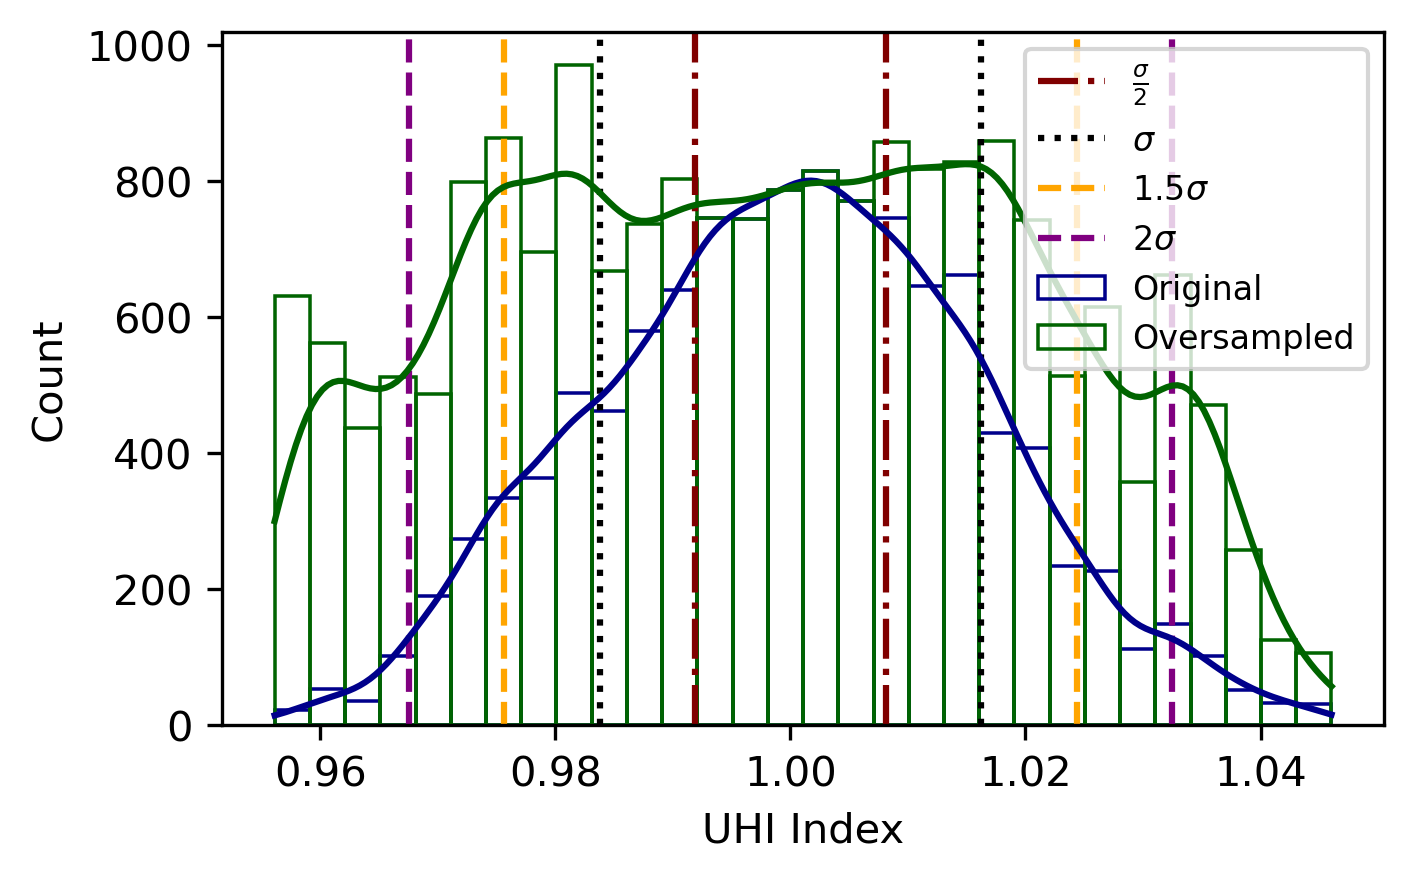

In [16]:
# Std deviation
sigma = 0.016238

# Plot
"""fig, ax = subplots(1, 1, figsize = (5, 3), dpi = 300)
axvline(x = 1.0 + sigma, color = 'black', ls = '--')
axvline(x = 1.0 - sigma, color = 'black', ls = '--')
axvline(x = 1.0 + sigma/2.0, color = 'maroon', ls = '-.')
axvline(x = 1.0 - sigma/2.0, color = 'maroon', ls = '-.')
histplot(data = df, x = "UHI Index", bins = 50, kde=True, ax = ax)"""

fig, ax = subplots(1, 1, figsize = (5, 3), dpi = 300)
axvline(x = 1.0 + sigma/2.0, color = 'maroon', ls = '-.', label = r"$\frac{\sigma}{2}$")
axvline(x = 1.0 - sigma/2.0, color = 'maroon', ls = '-.')
axvline(x = 1.0 + sigma, color = 'black', ls = ':', label = r"$\sigma$")
axvline(x = 1.0 - sigma, color = 'black', ls = ':')
axvline(x = 1.0 + 1.5*sigma, color = 'orange', ls = '--', label = r"$1.5\sigma$")
axvline(x = 1.0 - 1.5*sigma, color = 'orange', ls = '--')
axvline(x = 1.0 + 2.0*sigma, color = 'purple', ls = '--', label = r"$2\sigma$")
axvline(x = 1.0 - 2.0*sigma, color = 'purple', ls = '--')
histplot(data = df, x = "UHI Index", color = 'darkblue', label = 'Original',  bins = 30, kde = True, fill = False, ax = ax)
histplot(data = df_over, x = "UHI Index", color = 'darkgreen', label = 'Oversampled', bins = 30, kde = True, fill = False, ax = ax)
ax.legend(fontsize = 8)

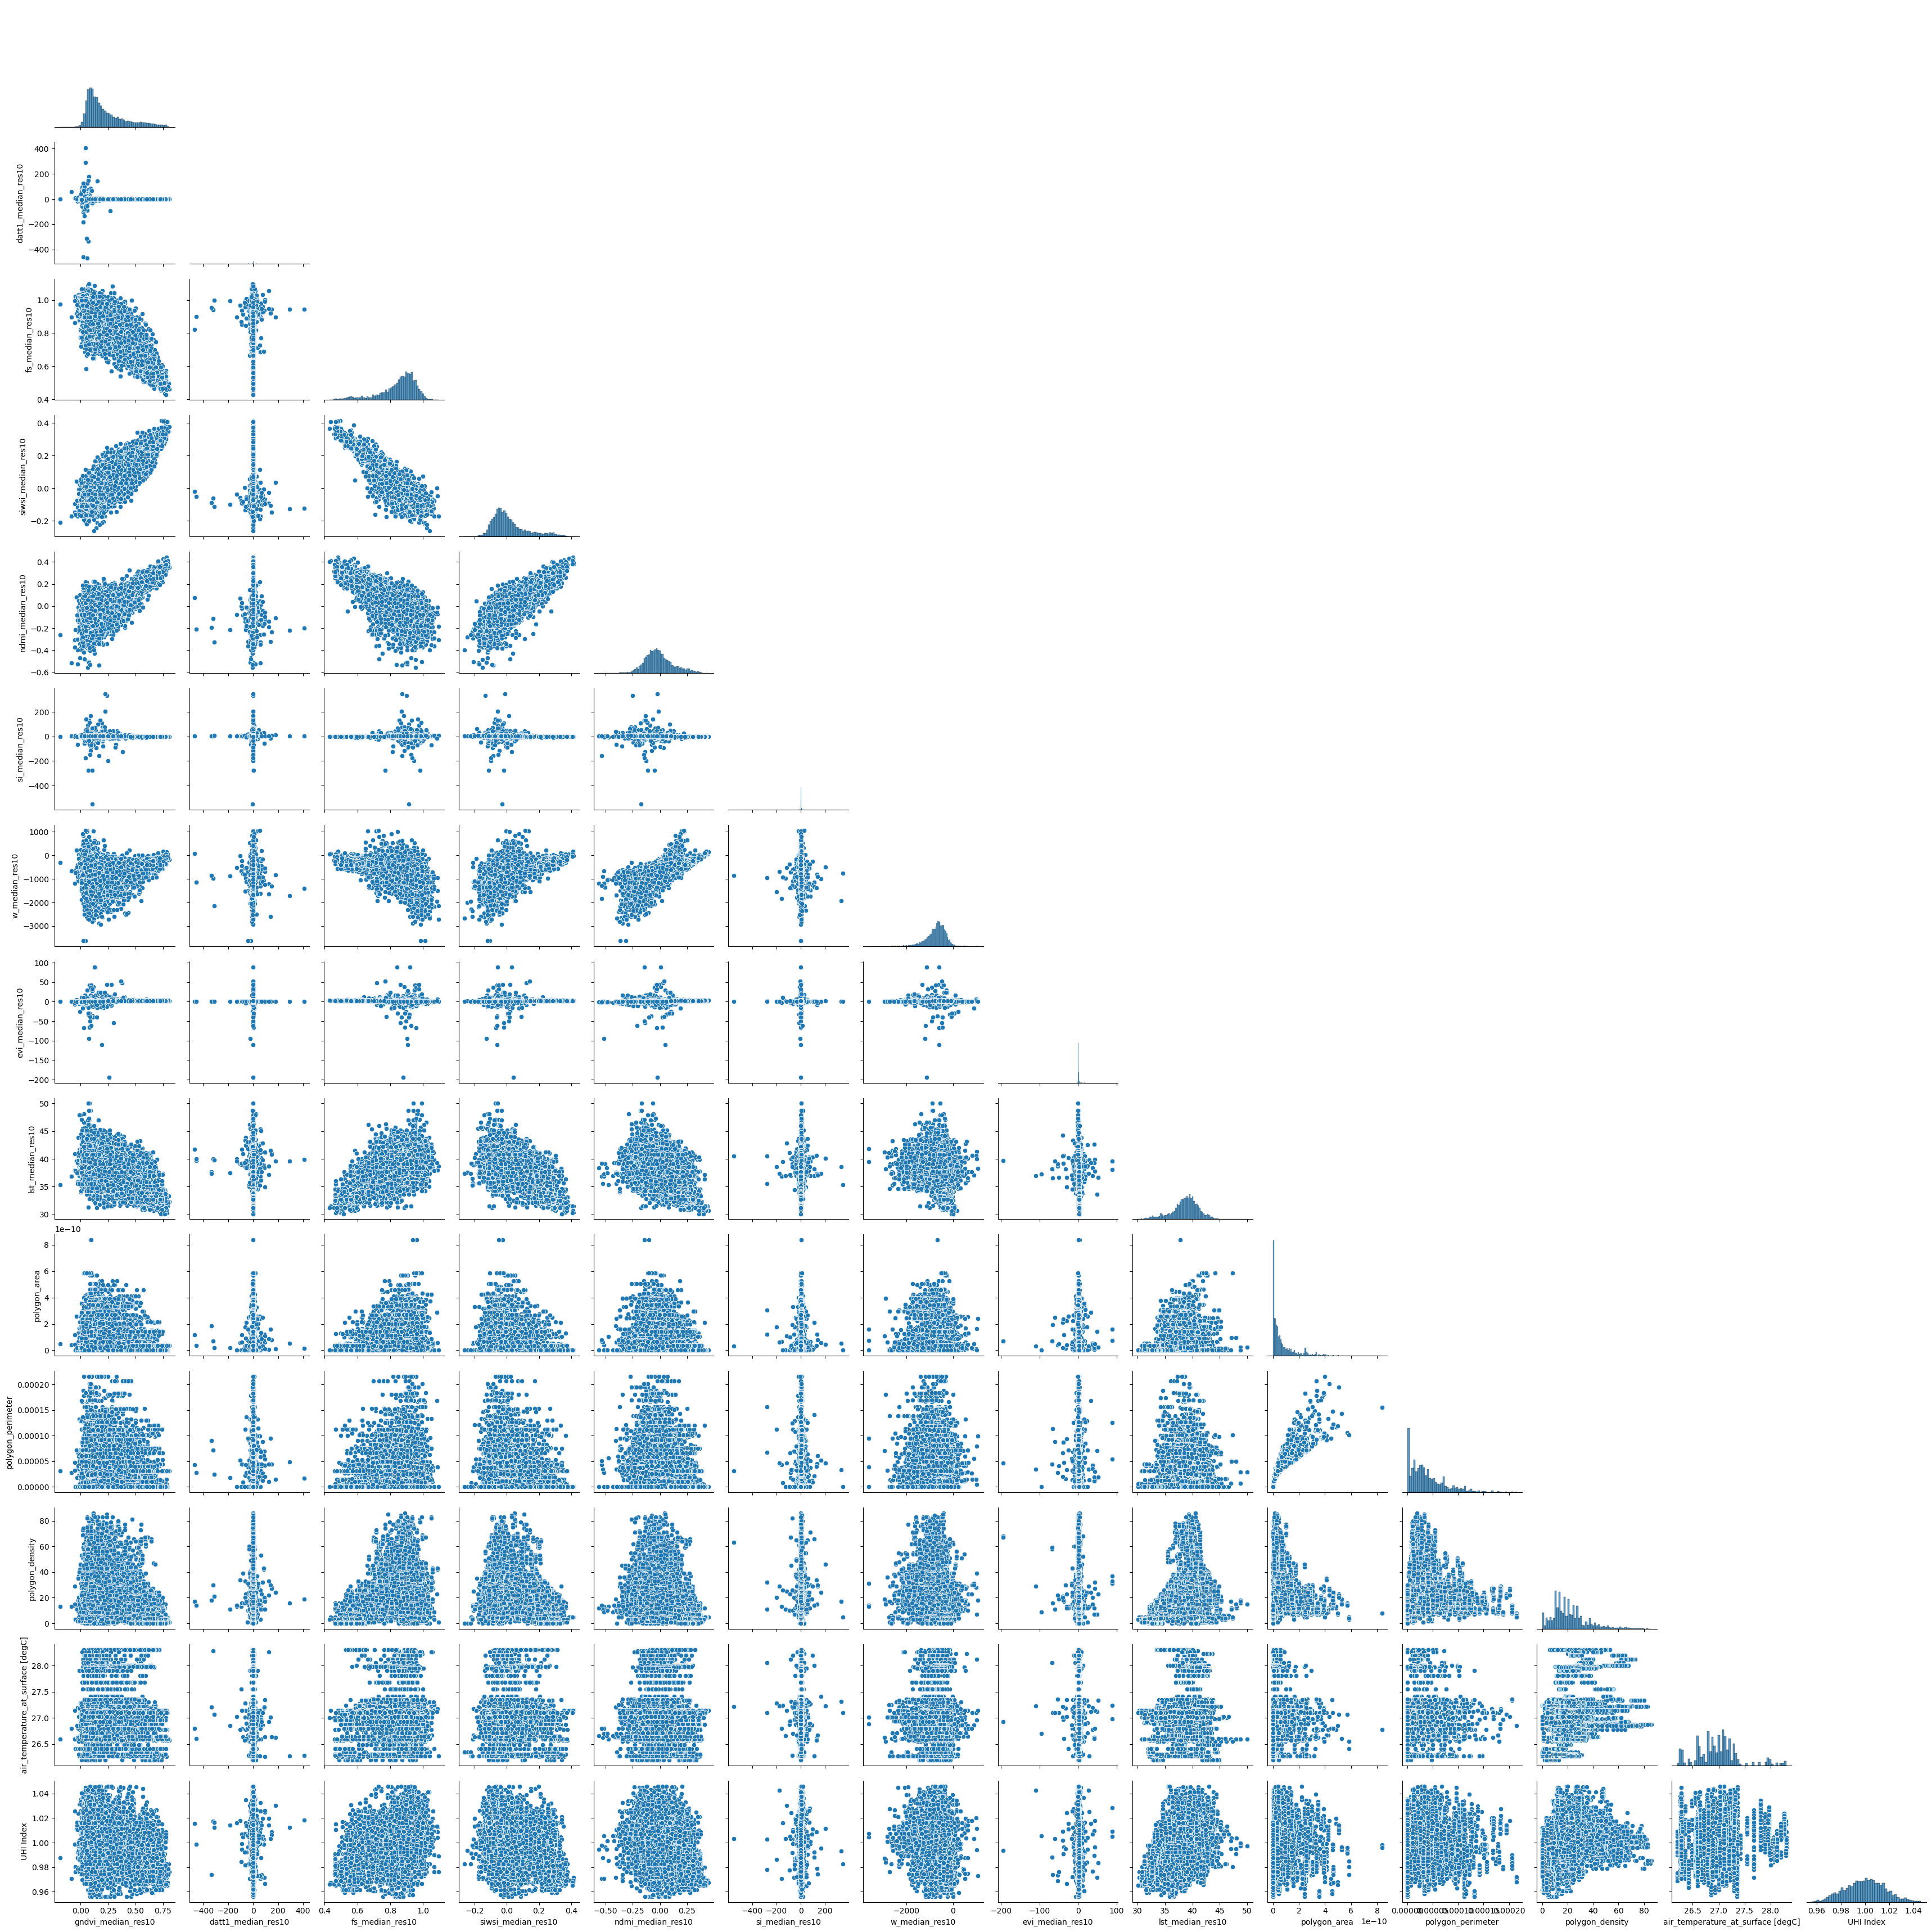

In [227]:
pairplot(df, corner = True)

In [100]:
# Pipeline to apply to training numerical predictors
numerical_pipeline = Pipeline(steps = [("imputer", SimpleImputer(strategy = "mean")),
                                       ("scaler", StandardScaler())])

In [101]:
preprocessor = ColumnTransformer([("numerical_pipeline", numerical_pipeline, df.columns[:-1])])

In [102]:
input_feature_df = df.drop(columns = ["UHI Index"], axis = 1)

In [103]:
input_feature_arr = preprocessor.fit_transform(input_feature_df)

In [112]:
df_new = pd.DataFrame(np.c_[input_feature_arr, np.array(df[df.columns[-1]])])

In [113]:
df_new.rename(columns = {13: "UHI Index"}, inplace = True)

In [114]:
df_new.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,UHI Index
count,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,11229.000000
mean,1.721147e-16,-1.581937e-18,3.543538e-16,-3.037319e-17,2.024879e-17,1.771769e-17,-1.822391e-16,3.037319e-17,3.644782e-16,-6.580857e-17,-4.049758e-17,-1.012440e-17,4.819212e-15,1.000001
std,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,0.016238
min,-2.352210e+00,-3.450752e+01,-3.656758e+00,-2.569003e+00,-4.157917e+00,-4.921298e+01,-6.926961e+00,-4.538291e+01,-3.406382e+00,-7.666128e-01,-1.075364e+00,-1.521620e+00,-1.898800e+00,0.956122
25%,-7.428205e-01,-6.493403e-03,-4.210857e-01,-6.802328e-01,-6.567120e-01,-1.268779e-01,-4.834402e-01,-1.626746e-01,-5.075800e-01,-6.810969e-01,-7.282566e-01,-6.706536e-01,-6.479516e-01,0.988577
50%,-3.423621e-01,3.390456e-02,2.484064e-01,-2.624380e-01,-1.112694e-01,-2.242329e-02,1.448934e-01,-4.910735e-02,9.892613e-02,-4.031552e-01,-2.702050e-01,-1.742565e-01,-3.603166e-03,1.000237
75%,4.766932e-01,4.965156e-02,6.874663e-01,4.116066e-01,5.539820e-01,8.572610e-02,6.510522e-01,1.538404e-01,6.189815e-01,2.557105e-01,4.571276e-01,4.639683e-01,4.684987e-01,1.011176
max,3.304033e+00,3.004013e+01,2.173644e+00,3.655408e+00,3.430550e+00,3.065895e+01,4.254628e+00,2.055450e+01,4.447804e+00,7.864151e+00,4.750310e+00,4.576972e+00,3.177989e+00,1.046036


In [115]:
# Count unique values
np.unique(df_new['UHI Index'].values, return_counts = True)[0].size

595

In [211]:
# Bin the data
uhi_binned = pd.cut(df_new['UHI Index'], bins = 75, include_lowest = True)

In [212]:
for uhi, interval in zip(df_new['UHI Index'], uhi_binned[:10]):
    print(uhi, interval)

1.030288903 (1.029, 1.03]
1.030288903 (1.029, 1.03]
1.023797758 (1.023, 1.024]
1.023797758 (1.023, 1.024]
1.021634043 (1.021, 1.022]
1.021634043 (1.021, 1.022]
1.015142899 (1.015, 1.016]
1.015142899 (1.015, 1.016]
1.012979184 (1.012, 1.014]
1.012979184 (1.012, 1.014]


In [213]:
# List of binned uhi indeces
binned_uhi_indeces = []

# Assing a binned value of the UHI index based on its interval
for interval in uhi_binned:
    binned_uhi_indeces.append(str((interval.right + interval.left)/2.0))
    #binned_uhi_indeces.append((interval.right + interval.left)/2.0)
     
# Save array of binned UHI indeces as a column
df_new['UHI Index binned'] =  binned_uhi_indeces

In [214]:
df_new.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,UHI Index,UHI Index binned
0,0.004927,0.023250,-0.112343,-0.363694,0.157134,-0.026816,0.399334,0.069029,0.800663,-0.688023,-0.697543,0.747624,-0.822282,1.030289,1.0295
1,0.004927,0.023250,-0.112343,-0.363694,0.157134,-0.026816,0.399334,0.069029,0.800663,-0.688023,-0.697543,0.676710,-0.822282,1.030289,1.0295
2,1.348300,0.037920,-1.000235,1.555043,1.459163,-0.161991,0.900527,0.171799,0.470394,1.307039,2.089260,0.747624,-0.822282,1.023798,1.0234999999999999
3,1.465976,0.036055,-1.000235,1.555043,1.391445,-0.146670,0.805046,0.190507,0.470394,1.307039,2.089260,0.747624,-0.822282,1.023798,1.0234999999999999
4,1.435443,0.036991,-0.883545,1.228007,1.163259,-0.209431,0.561534,0.334249,0.321807,1.307039,2.089260,0.747624,-0.822282,1.021634,1.0215


In [215]:
np.unique(df_new['UHI Index binned'].values, return_counts = True)[1]

array([ 13,   9,  10,  16,  27,  12,  12,  25,  47,  40,  75,  51, 110,
        62, 166, 100, 198, 108, 131, 160, 198, 192, 173, 192, 195, 224,
       247, 231, 224, 293, 267, 329, 293, 342, 259, 351, 307, 317, 315,
       311, 333, 258, 342, 223, 360, 274, 251, 259, 200, 324, 145, 212,
       138, 156, 186,  84, 116, 101, 105,  54,  45,  60,  27, 101,  27,
        49,  18,  48,   6,  32,  13,  11,  19,   9,  11])

In [216]:
max_samples_in_a_bin = np.unique(df_new['UHI Index binned'].values, return_counts = True)[1].max()

In [217]:
dict_of_classes = {c : max_samples_in_a_bin for c in np.unique(df_new['UHI Index binned'].values)}

In [218]:
dict_of_classes

{'0.956': np.int64(360),
 '0.958': np.int64(360),
 '0.9595': np.int64(360),
 '0.9604999999999999': np.int64(360),
 '0.9615': np.int64(360),
 '0.9624999999999999': np.int64(360),
 '0.964': np.int64(360),
 '0.9655': np.int64(360),
 '0.9664999999999999': np.int64(360),
 '0.9675': np.int64(360),
 '0.9684999999999999': np.int64(360),
 '0.97': np.int64(360),
 '0.9715': np.int64(360),
 '0.9724999999999999': np.int64(360),
 '0.9735': np.int64(360),
 '0.9744999999999999': np.int64(360),
 '0.976': np.int64(360),
 '0.9775': np.int64(360),
 '0.9784999999999999': np.int64(360),
 '0.9795': np.int64(360),
 '0.9804999999999999': np.int64(360),
 '0.9815': np.int64(360),
 '0.983': np.int64(360),
 '0.9844999999999999': np.int64(360),
 '0.9855': np.int64(360),
 '0.9864999999999999': np.int64(360),
 '0.9875': np.int64(360),
 '0.989': np.int64(360),
 '0.9904999999999999': np.int64(360),
 '0.9915': np.int64(360),
 '0.9924999999999999': np.int64(360),
 '0.9935': np.int64(360),
 '0.995': np.int64(360),
 '0.996

In [219]:
# Split variables in predictors and responses
X = df_new.drop(columns = ['UHI Index', 'UHI Index binned'], axis = 1)
y = df_new['UHI Index binned']

# SMOTE
# Resampling the minority class. The strategy can be changed as required.
sm = SMOTE(sampling_strategy = dict_of_classes, random_state = 30)

# Fit the model to generate the data
X_SMOTE, y_SMOTE = sm.fit_resample(X, y)

In [220]:
# SMOTE DataFrame
df_smote = pd.concat((X_SMOTE, y_SMOTE), axis = 1)

In [221]:
df_smote['UHI Index binned'] = df_smote['UHI Index binned'].astype(float)

In [222]:
df_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   0                 27000 non-null  float64
 1   1                 27000 non-null  float64
 2   2                 27000 non-null  float64
 3   3                 27000 non-null  float64
 4   4                 27000 non-null  float64
 5   5                 27000 non-null  float64
 6   6                 27000 non-null  float64
 7   7                 27000 non-null  float64
 8   8                 27000 non-null  float64
 9   9                 27000 non-null  float64
 10  10                27000 non-null  float64
 11  11                27000 non-null  float64
 12  12                27000 non-null  float64
 13  UHI Index binned  27000 non-null  float64
dtypes: float64(14)
memory usage: 2.9 MB


In [225]:
df_smote.duplicated().sum()

np.int64(1339)

<Axes: xlabel='UHI Index binned', ylabel='Count'>

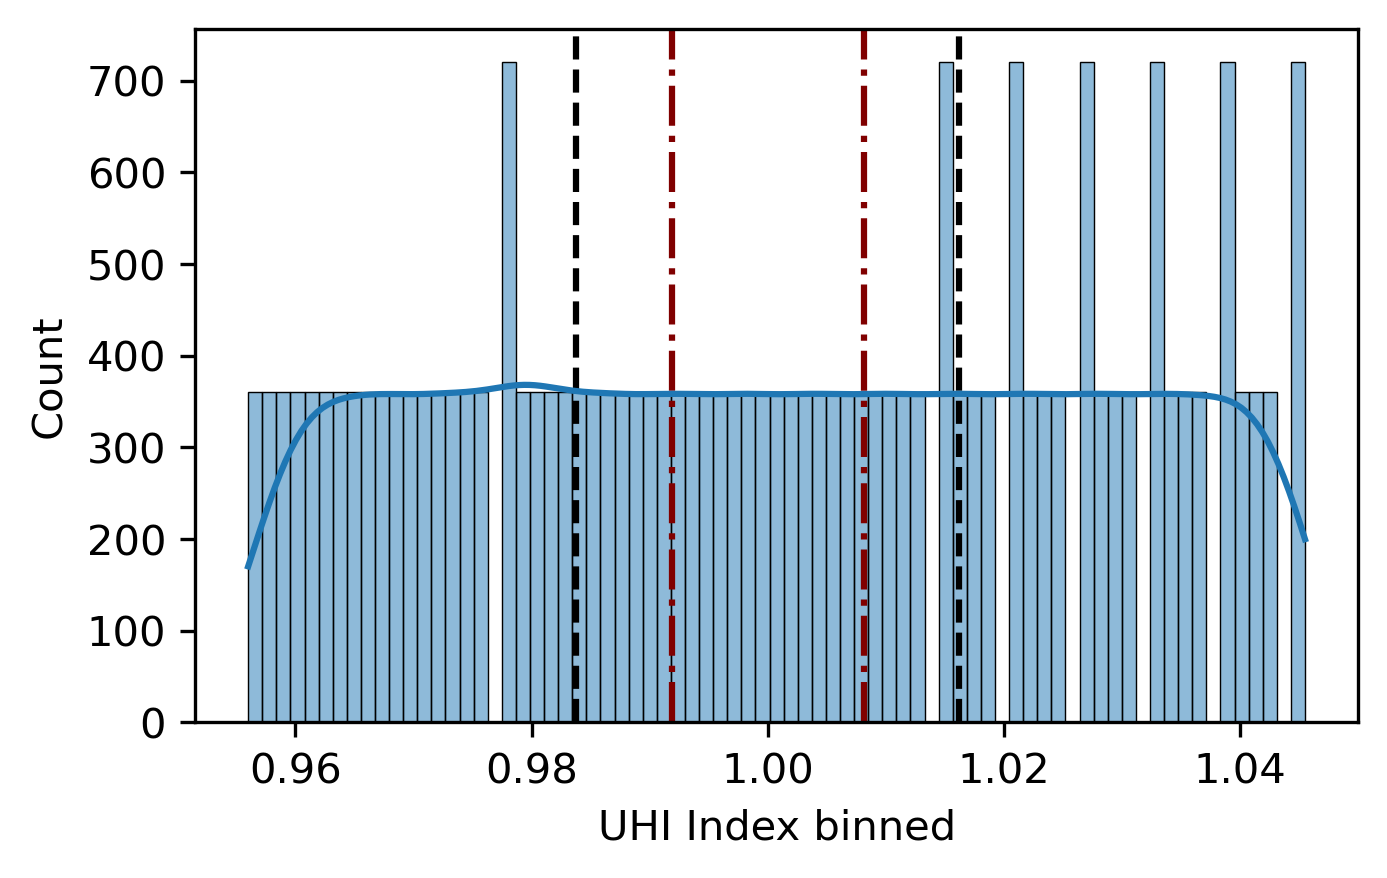

In [223]:
# Plot
fig, ax = subplots(1, 1, figsize = (5, 3), dpi = 300)
axvline(x = 1.0 + sigma, color = 'black', ls = '--')
axvline(x = 1.0 - sigma, color = 'black', ls = '--')
axvline(x = 1.0 + sigma/2.0, color = 'maroon', ls = '-.')
axvline(x = 1.0 - sigma/2.0, color = 'maroon', ls = '-.')
histplot(data = df_smote, x = "UHI Index binned", bins = 75, kde=True, ax = ax)

In [224]:
df_smote.to_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv', index = False)